# Developing an AI Sommelier For Wine Quality Prediction

---
embed-resources: true
---

## Introduction

Wine quality is usually judged by trained sommeliers, but our startup aims to develop an AI-based Sommelier that can predict wine quality using chemical properties instead of human expertise. To achieve this, we trained machine learning models, including Decision Trees and K-Nearest Neighbors (KNN), using past wine quality ratings. This report explains how these models were developed, the challenges faced—such as imbalanced data and misclassification errors—and whether the models are reliable enough for real-world use.

## Methods

In [3]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# machine learning
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeClassifier

# preprocessing imports
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

### Data

In [4]:
# load data
wine_train = pd.read_parquet(
    "https://cs307.org/lab/data/wine-train.parquet",
)
wine_test = pd.read_parquet(
    "https://cs307.org/lab/data/wine-test.parquet",
)

#### Data Dictionary
Each observation in the train, test, and (hidden) production data contains information about a particular Portuguese “Vinho Verde” wine.

Vinho verde is a unique product from the Minho (northwest) region of Portugal. Medium in alcohol, is it particularly appreciated due to its freshness (specially in the summer).

Original and complete documentation for this data can be found in the original paper. Additionally, minimal documentation is provided by the UCI MLR.

#### Response

`quality`

- `[int64]` the quality of the wine based on evaluation by a minimum of three sensory assessors (using blind tastes), which graded the wine in a scale that ranges from 0 (very bad) to 10 (excellent)

#### Features

`color`

- `[object]` the (human perceivable) color of the wine, red or white

`fixed acidity`

- `[float64]` grams of tartaric acid per cubic decimeter

`volatile acidity`

- `[float64]` grams of acetic acid per cubic decimeter

`citric acid`

- `[float64]` grams of citric acid per cubic decimeter

`residual sugar`

- `[float64]` grams of residual sugar per cubic decimeter

`chlorides`

- `[float64]` grams of sodium chloride cubic decimeter

`free sulfur dioxide`

- `[float64]` milligrams of free sulfur dioxide per cubic decimeter

`total sulfur dioxide`

- `[float64]` milligrams of total sulfur dioxide per cubic decimeter

`density`

- `[float64]` the total density of the wine in grams per cubic centimeter

`pH`

- `[float64]` the acidity of the wine measured using pH

`sulphates`

- `[float64]` grams of potassium sulphate cubic decimeter

`alcohol`

- `[float64]` percent alcohol by volume

In [75]:
# summary statistics
wine_train.iloc[:,1:12].describe()

,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4157.000000,3958.000000,3917.000000,4157.000000,4133.000000,4157.000000,4157.000000,3921.000000,3934.000000,3961.000000,4157.000000
mean,0.342403,0.316478,5.430406,0.056358,30.600048,115.221915,0.994710,3.218454,0.531784,10.502847,5.814289
std,0.166465,0.145276,4.750618,0.035460,17.906396,56.581139,0.003004,0.159184,0.150914,1.189918,0.868748
min,0.080000,0.000000,0.600000,0.012000,1.000000,6.000000,0.987110,2.740000,0.230000,8.000000,3.000000
25%,0.230000,0.240000,1.800000,0.038000,17.000000,77.000000,0.992380,3.110000,0.430000,9.500000,5.000000
50%,0.300000,0.310000,3.000000,0.048000,29.000000,118.000000,0.994900,3.210000,0.505000,10.300000,6.000000
75%,0.410000,0.390000,8.100000,0.066000,41.000000,155.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,1.330000,1.230000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


These values highlight the distribution of each feature, revealing differences in scale. For example, residual sugar ranges from 0.6 to 65.8, while chlorides have much smaller values, ranging from 0.012 to 0.611. Similarly, total sulfur dioxide has a wide spread (6 to 440), whereas pH has a much narrower range (2.74 to 4.01).

Standardization is essential when using K-Nearest Neighbors (KNN) because the algorithm relies on distance metrics (e.g., Euclidean distance). Features with larger magnitudes (such as residual sugar or total sulfur dioxide) will dominate the distance calculation, leading to biased predictions. We need to standardize the data to ensure that all features contribute equally to the distance calculation when using knn model.

Also, we have some missing values in the dataset. We will impute the missing values with the median of the respective column.

In [87]:
pd.DataFrame(wine_train["quality"].value_counts())

,count
quality,
6,1810
5,1385
7,686
4,133
8,122
3,19
9,2


As we can see, the quality of the wine is a discrete variable with values ranging from 3 to 9. We will tret this as a classification problem. Also, the data is imbalanced.

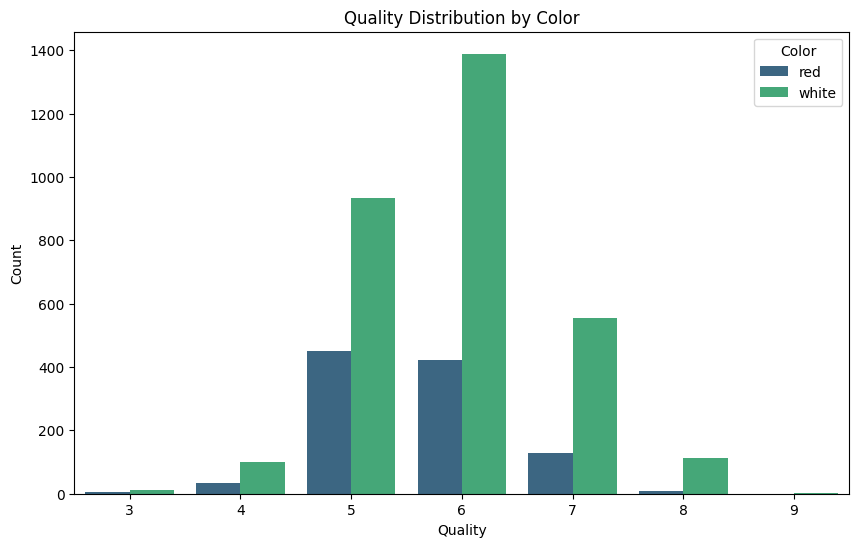

In [42]:
# exploratory visualization
plt.figure(figsize=(10, 6))
sns.countplot(data=wine_train, x="quality", hue="color", palette="viridis")

plt.xlabel("Quality")
plt.ylabel("Count")
plt.title("Quality Distribution by Color")
plt.legend(title="Color")
plt.show()

The chart reveals that white wines are more frequent across most quality levels, particularly around quality 6, while red wines have a lower overall count. This visualization is crucial for identifying potential class imbalances. Additionally, it highlights the relationship between wine color and quality, suggesting that color may be a significant predictor in the model.

### Models

In [78]:
# process data for ML
# create X and y for train
X_train = wine_train.drop("quality", axis=1)
y_train = wine_train["quality"]

# create X and y for test
X_test = wine_test.drop("quality", axis=1)
y_test = wine_test["quality"]

In [79]:
numeric_features = ['volatile acidity', 'chlorides', 'density', 'alcohol','citric acid','total sulfur dioxide','fixed acidity','sulphates','residual sugar','free sulfur dioxide','pH']
categorical_features = ['color']
features = numeric_features + categorical_features
target = "quality"

In [80]:
# train models
dt = DecisionTreeRegressor()
dtc = DecisionTreeClassifier()
# define preprocessing for numeric features
numeric_transformer = make_pipeline(
    SimpleImputer(strategy="median"),
)

# define preprocessing for categorical features
categorical_transformer = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="infrequent_if_exist"),
)

# create general preprocessor
preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (categorical_transformer, categorical_features),
    remainder="drop",
)
# define the parameter grid
# check error

param_grid = {
    
    "decisiontreeclassifier__min_samples_split": [50, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600],
}

# create the pipeline
pipeline = make_pipeline(
    preprocessor,
    dtc,
)

# create the grid search
mod = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
)

# fit the grid search
mod.fit(X_train, y_train)

# print the best parameters and the corresponding score
print(f"Best Parameters: {mod.best_params_}")
print(f"Best Cross-Validated MAE: {mod.best_score_}")

c:\Users\changrong Wu\OneDrive\桌面\cs307\.venv\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'decisiontreeclassifier__min_samples_split': 500}
Best Cross-Validated MAE: -0.5248975978894752


In [88]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
# train models
knn = KNeighborsClassifier()
# define preprocessing for numeric features
numeric_transformer = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
)

# define preprocessing for categorical features
categorical_transformer = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="infrequent_if_exist"),
)

# create general preprocessor
preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (categorical_transformer, categorical_features),
    remainder="drop",
)
# define the parameter grid
param_grid = {
    "kneighborsclassifier__n_neighbors": [1, 5, 10, 15, 20, 25],
    "kneighborsclassifier__p": [1, 2],
}

# create the pipeline
pipeline = make_pipeline(
    preprocessor,
    knn,
)

# create the grid search
mod = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
)

# fit the grid search
mod.fit(X_train, y_train)

# print the best parameters and the corresponding score
print(f"Best Parameters: {mod.best_params_}")
print(f"Best Cross-Validated MAE: {mod.best_score_}")

c:\Users\changrong Wu\OneDrive\桌面\cs307\.venv\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'kneighborsclassifier__n_neighbors': 1, 'kneighborsclassifier__p': 1}
Best Cross-Validated MAE: -0.49339014625566974


The training results show the optimal cross-validation performance for two models: Decision Tree Classifier and K-Nearest Neighbors (KNN) Classifier. The best Decision Tree Classifier was found with a min_samples_split value of 500, achieving a cross-validated Mean Absolute Error (MAE) of approximately 0.525. This suggests that the model's predictions, on average, deviate by about 0.525 quality points from the true values. Meanwhile, the KNN Classifier performed best with n_neighbors = 1 and p = 1 (Manhattan Distance), yielding a cross-validated Root Mean Squared Error (RMSE) of approximately 0.493. Notably, an n_neighbors value of 1 means that predictions are directly based on the closest single training instance, which could lead to overfitting.

We go with the KNN model as it has the lowest MAE value.

## Results

In [82]:
# report model metrics
mean_absolute_error(mod.predict(X_test), y_test)

0.4634615384615385

The K-Nearest Neighbors (KNN) model achieved a test MAE of 0.4634615384615385. This means that our predictions deviate from the actual wine quality scores by approximately 0.46 points.

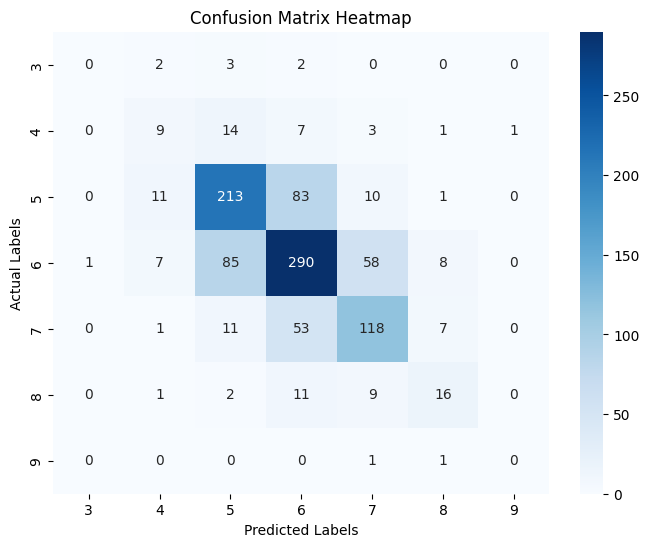

In [54]:
from sklearn.metrics import confusion_matrix

# Get predictions on the test set
y_pred = mod.best_estimator_.predict(X_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=mod.classes_, yticklabels=mod.classes_)

# Labels and title
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix Heatmap")
plt.show()

The confusion matrix heatmap provides a visual representation of the model's classification performance, showing how often actual quality labels were correctly or incorrectly predicted. The diagonal values represent correct classifications, with the most accurate predictions occurring for quality levels 5 and 6, as indicated by the darker blue shades. However, significant misclassifications are observed between adjacent quality levels, particularly between quality 5 and 6 and quality 6 and 7, suggesting that the model struggles to differentiate wines with similar quality scores. Additionally, rare quality levels, such as 3 and 9, have very few predictions, highlighting class imbalance issue that may require oversampling or weighting adjustments. While the model performs reasonably well, its tendency to misclassify neighboring quality scores suggests that wine quality ratings have overlapping characteristics, making precise classification challenging. Analyzing this confusion matrix allows for further model refinement, such as adjusting classification thresholds or incorporating techniques to handle imbalanced data more effectively.

In [68]:
# serialize model
from joblib import dump
dump(mod, "wine.joblib")

['wine.joblib']

## Discussion

After evaluating the performance of the Decision Tree Classifier and K-Nearest Neighbors (KNN) model, I would not recommend using the current model in practice. While the models demonstrate a relatively low Mean Absolute Error (MAE), the heat map shows opposite direction. More critically, the dataset used for training exhibits class imbalance, meaning that some wine quality levels are significantly underrepresented. This imbalance can lead to biased predictions, where the model favors the majority classes while failing to correctly classify less frequent quality levels. Given that the AI Sommelier is expected to provide accurate wine quality predictions, relying on a model that struggles with minority classes could lead to misleading results and potential financial losses.

In the laboratory setting described in the scenario, the AI Sommelier is intended to replace human sommeliers in assessing wine quality based on physicochemical data. However, wine quality is inherently subjective and influenced by factors beyond chemical composition, such as regional preferences, consumer expectations, and sensory characteristics like aroma and mouthfeel. If the model consistently misclassifies high-quality wines as lower-quality or vice versa, it could negatively impact pricing strategies and consumer trust. Additionally, the confusion matrix suggests significant misclassification between adjacent quality levels, meaning that even small variations in physicochemical properties could lead to incorrect predictions.

If the startup intends to pursue an AI Sommelier, improvements must be made before considering deployment.First, the class imbalance issue must be addressed using techniques such as oversampling (e.g., SMOTE), undersampling, or class weighting to ensure that all quality levels are adequately represented in training. Second, alternative models, such as Random Forest, Gradient Boosting, or Neural Networks, should be tested to improve predictive performance. Lastly, a human-in-the-loop system could be implemented, where the AI assists sommeliers rather than replacing them outright, ensuring misclassifications do not lead to irreversible business consequences.

In conclusion, while the idea of an AI Sommelier is promising, the current model is not ready for practical use. The risks of misclassification outweigh the benefits, and further refinements are needed to ensure the model aligns with real-world expectations and business needs.